# Model Comparison - Competition-Aware CV

**Scoring**: `Score = TP×10 - FP×5 - NoVariables×200`  (cap: 1 000 contacts per submission)

**CV setup**: 5-fold StratifiedKFold -> each validation fold is exactly **1 000 observations**.  
For each fold the model can contact *up to* 1 000 customers; `sweep_cutoff` finds the optimal N ≤ 1 000 that maximises the score. Contacting fewer is valid and sometimes better.

**Baseline to beat**: **3 885** (LR-L1, 5 features, from `first_diagnostics.py`)

In [2]:
import sys, warnings, copy, time
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from data import load_data
from features import l1_path_ranking, mutual_info_ranking
from models import get_models
from cv import competition_cv_evaluate
from scoring import sweep_cutoff
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)
BASELINE = 3885

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

X_train, y_train, X_test, Xs_train, Xs_test, scaler = load_data()
print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Positive rate: {y_train.mean():.3f}')

Train: (5000, 500)   Test: (5000, 500)
Positive rate: 0.498


## 1. Feature Selection: L1 Path vs Mutual Information

We compare two unsupervised-style feature importance signals:
- **L1 path order**: features that enter the Lasso path at lower regularization are more predictive
- **Mutual information**: measures non-linear dependence between feature and label

Agreement between methods strengthens confidence in a feature; disagreement warrants closer inspection.

In [3]:
print('Computing L1 path ranking...')
l1_rank = l1_path_ranking(Xs_train, y_train)

print('Computing mutual information ranking...')
mi_rank = mutual_info_ranking(X_train, y_train)

TOP_K = 15
l1_top = set(l1_rank[:TOP_K].tolist())
mi_top = set(mi_rank[:TOP_K].tolist())
overlap = l1_top & mi_top

df_feat = pd.DataFrame({
    'L1 rank': {j: i+1 for i, j in enumerate(l1_rank[:TOP_K])},
    'MI rank': {j: list(mi_rank).index(j)+1 if j in mi_rank[:TOP_K] else '>15' for j in l1_top},
}).fillna('>15')
df_feat.index = [f'V{j+1}' for j in df_feat.index]
df_feat['In both top-15'] = df_feat.index.map(lambda x: 'ok' if int(x[1:])-1 in overlap else '')

print(f'\nTop-{TOP_K} features by each method (overlap = {len(overlap)}/{TOP_K}):')
display(df_feat.sort_values('L1 rank'))

Computing L1 path ranking...
Computing mutual information ranking...

Top-15 features by each method (overlap = 0/15):


,L1 rank,MI rank,In both top-15
V224,1,>15,
V329,2,>15,
V345,3,>15,
V199,4,>15,
V175,5,>15,
V390,6,>15,
V32,7,>15,
V161,8,>15,
V309,9,>15,
V469,10,>15,


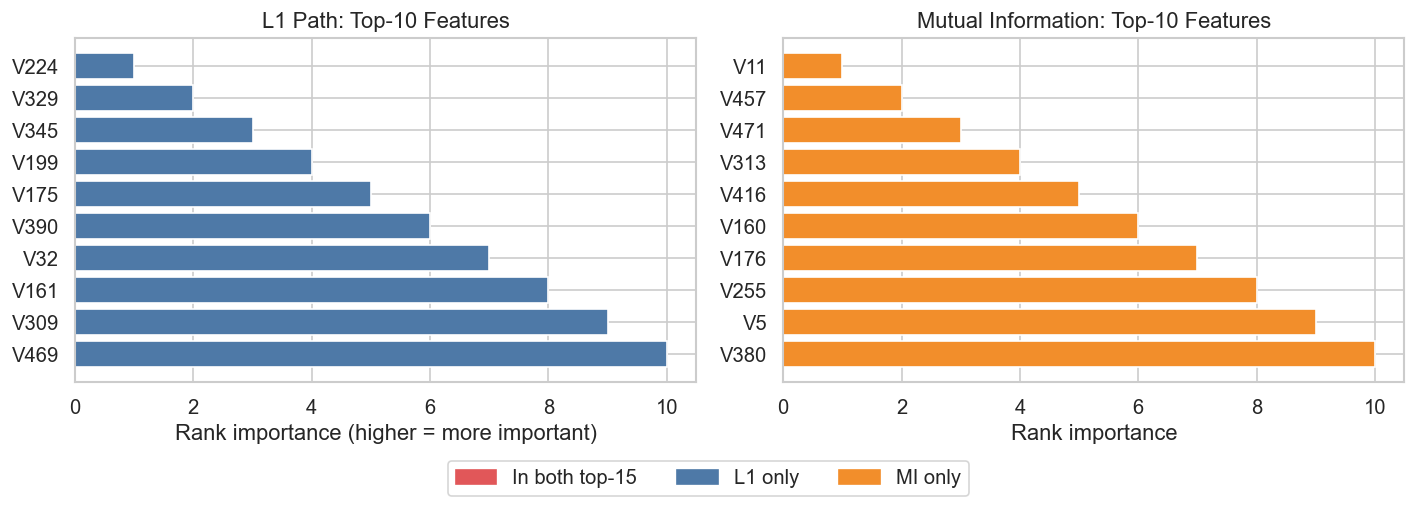

In [4]:
# Side-by-side bar of top-10 L1 vs MI ranks
k_show = 10
l1_labels = [f'V{j+1}' for j in l1_rank[:k_show]]
mi_labels  = [f'V{j+1}' for j in mi_rank[:k_show]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_l1 = ['#e15759' if f in [f'V{j+1}' for j in overlap] else '#4e79a7' for f in l1_labels]
colors_mi = ['#e15759' if f in [f'V{j+1}' for j in overlap] else '#f28e2b' for f in mi_labels]

axes[0].barh(l1_labels[::-1], range(k_show, 0, -1), color=colors_l1[::-1], edgecolor='white')
axes[0].set_title('L1 Path: Top-10 Features')
axes[0].set_xlabel('Rank importance (higher = more important)')

axes[1].barh(mi_labels[::-1], range(k_show, 0, -1), color=colors_mi[::-1], edgecolor='white')
axes[1].set_title('Mutual Information: Top-10 Features')
axes[1].set_xlabel('Rank importance')

red_patch  = mpatches.Patch(color='#e15759', label='In both top-15')
blue_patch = mpatches.Patch(color='#4e79a7', label='L1 only')
org_patch  = mpatches.Patch(color='#f28e2b', label='MI only')
fig.legend(handles=[red_patch, blue_patch, org_patch], loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(FIGURES / '07_feat_selection.png')
plt.show()

## 2. Score vs Number of Features (LR-L1 sweep)

Each additional feature costs EUR 200 (NoVariables × 200). This plot shows the trade-off: adding a feature improves prediction but also increases the fixed cost. The optimal k is where the marginal benefit of an extra feature drops below 200.

In [ ]:
skf5 = StratifiedKFold(5, shuffle=True, random_state=0)
k_range = range(2, 31)
k_scores = []

print('Sweeping k=1..30 features for LR-L1 (global OOF protocol)...')
for k in k_range:
    feats = l1_rank[:k]
    p_cv = cross_val_predict(
        LogisticRegression(max_iter=2000, random_state=0),
        Xs_train[:, feats], y_train, cv=skf5, method='predict_proba'
    )[:, 1]
    # Global OOF: one sweep_cutoff on all 5000 OOF predictions
    # This mirrors the test scenario: choose up to 1000 from 5000.
    s, N, thr, tp, fp = sweep_cutoff(y_train, p_cv, k)
    k_scores.append(s)

best_k = int(np.argmax(k_scores)) + 1
print(f'Best k: {best_k}  (OOF score = {k_scores[best_k-1]})')


Sweeping k=1..30 features for LR-L1 (global OOF protocol)...
Best k: 5  (OOF score = 3925)


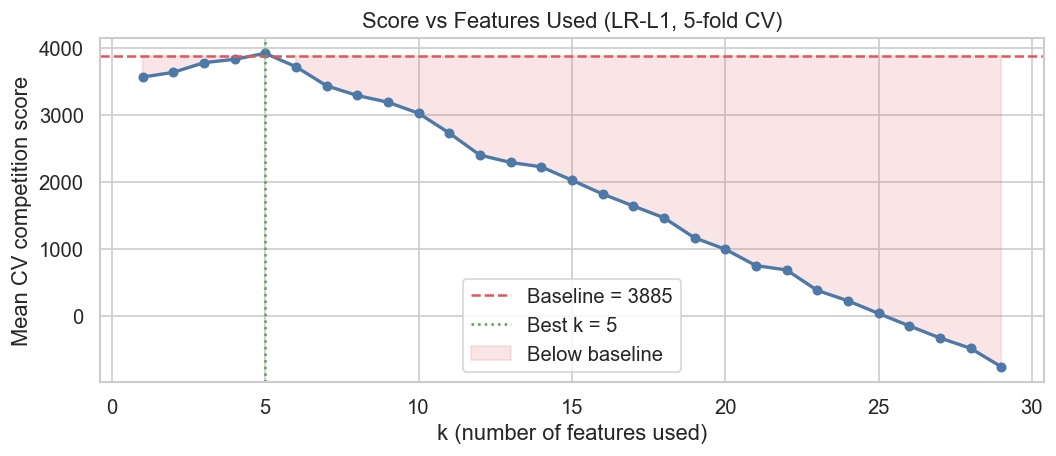

In [8]:
k_range_shifted = [k - 1 for k in k_range]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range_shifted), k_scores, 'o-', color='#4e79a7', linewidth=2, markersize=5)
ax.axhline(BASELINE, color='#e15759', linestyle='--', linewidth=1.5, label=f'Baseline = {BASELINE}')
ax.axvline(best_k, color='#59a14f', linestyle=':', linewidth=1.5, label=f'Best k = {best_k}')
ax.fill_between(list(k_range_shifted), k_scores, BASELINE,
                where=[s < BASELINE for s in k_scores],
                alpha=0.15, color='#e15759', label='Below baseline')
ax.set_xlabel('k (number of features used)')
ax.set_ylabel('Mean CV competition score')
ax.set_title('Score vs Features Used (LR-L1, 5-fold CV)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / '08_score_vs_k.png')
plt.show()

## 3. Model Comparison: CV Competition Scores

We evaluate five model families using the same 5-fold competition-aware CV loop. For tree-based models, `n_vars_used` counts only features with non-zero importance - the NoVariables cost reflects actual feature usage, not the full 500.

**Models compared**:
- `lr_l1`: Logistic Regression with L1 (Lasso) penalty - explicit sparsity, low NoVariables cost
- `lr_l2`: Logistic Regression with L2 (Ridge) penalty - all 500 features, high NoVariables cost
- `rf`: Random Forest - ensemble, selects features implicitly via splits
- `lgbm` / `gbm`: Gradient Boosting - often highest accuracy, but variable NoVariables cost
- `xgb`: XGBoost - similar to LGBM, different regularization

In [6]:
models = get_models()
results = {}

for name, model in models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    t0 = time.time()
    
    results[name] = competition_cv_evaluate(model, Xs_train, y_train)
    
    print(f'{time.time()-t0:.1f}s  '
          f'score={results[name]["score"]}  '
          f'N={results[name]["N"]}  '
          f'n_vars={results[name]["n_vars"]}  '
          f'threshold={results[name]["threshold"]:.4f}')

Evaluating lr_l1... 26.2s  score=-70580  N=1000  n_vars=372  threshold=0.6509
Evaluating lr_l2... 8.1s  score=-96585  N=1000  n_vars=500  threshold=0.7002
Evaluating rf... 61.0s  score=-94275  N=1000  n_vars=500  threshold=0.5633
Evaluating gbm... 273.2s  score=-71480  N=1000  n_vars=390  threshold=0.6447
Evaluating lgbm... 81.9s  score=-93500  N=1000  n_vars=498  threshold=0.7592


In [7]:
BASELINE = 3885 

rows = []
for name, res in results.items():
    rows.append({
        'Model': name,
        'OOF Score': res['score'],  
        'Beats Baseline': 'YES' if res['score'] > BASELINE else 'NO',
        'N Contacted': res['N'],            
        'Features Used': res['n_vars'],    
        'Threshold': f"{res['threshold']:.4f}", 
        'True Positives (TP)': res['tp'],
        'False Positives (FP)': res['fp']
    })

df_res = pd.DataFrame(rows).set_index('Model')
df_res = df_res.sort_values('OOF Score', ascending=False)

print(f'\n Baseline to beat: {BASELINE}')
display(df_res)


 Baseline to beat: 3885


,OOF Score,Beats Baseline,N Contacted,Features Used,Threshold,True Positives (TP),False Positives (FP)
Model,,,,,,,
lr_l1,-70580,NO,1000,372,0.6509,588,412
gbm,-71480,NO,1000,390,0.6447,768,232
lgbm,-93500,NO,1000,498,0.7592,740,260
rf,-94275,NO,1000,500,0.5633,715,285
lr_l2,-96585,NO,1000,500,0.7002,561,439


## 4. Optimal N and Threshold per Model

The global OOF protocol produces one optimal N (number of customers to contact) and one probability
threshold per model. A model that selects N close to the cap of 1,000 is confident it can profitably
contact most of its top-ranked customers. A model that selects fewer is either more conservative or
pays a high NoVariables cost that makes marginal contacts unprofitable.


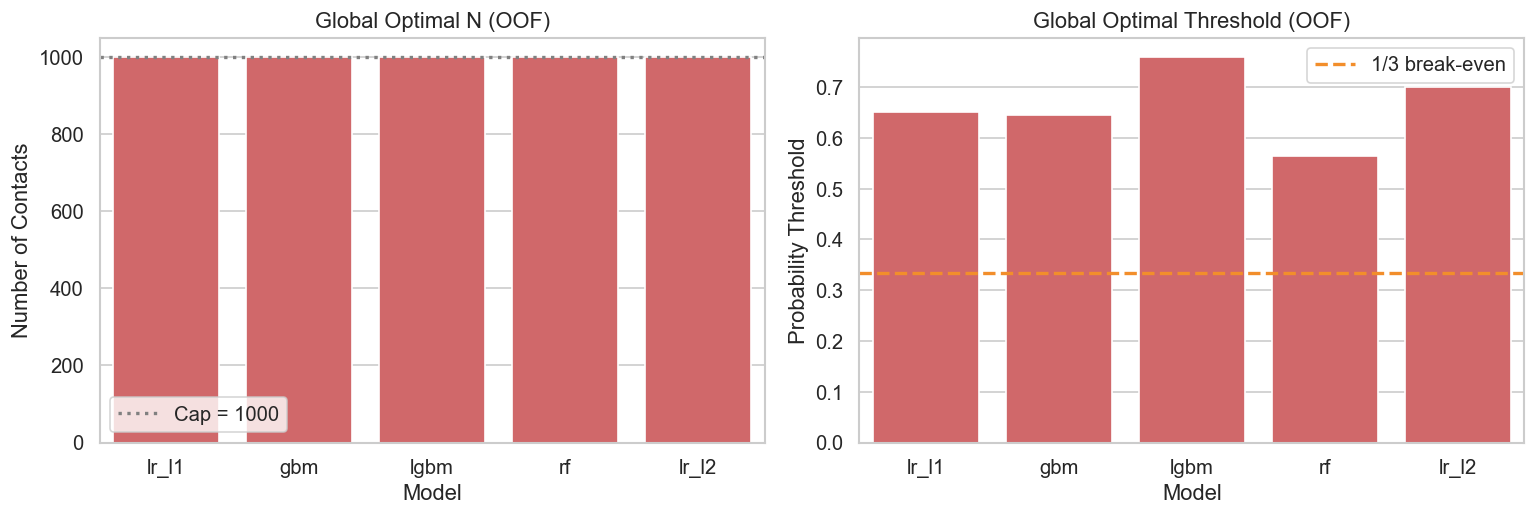

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
for name, res in results.items():
    plot_data.append({
        'Model': name, 
        'Score': res['score'],
        'N contacted': res['N'],
        'Threshold': res['threshold']
    })
df_plot = pd.DataFrame(plot_data)

df_plot = df_plot.sort_values('Score', ascending=False)

BASELINE = 3885
palette = ['#59a14f' if s > BASELINE else '#e15759' for s in df_plot['Score']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=df_plot, x='Model', y='N contacted', palette=palette, ax=axes[0])
axes[0].axhline(1000, color='gray', linestyle=':', linewidth=2, label='Cap = 1000')
axes[0].set_title('Global Optimal N (OOF)')
axes[0].set_ylabel('Number of Contacts')
axes[0].legend()

sns.barplot(data=df_plot, x='Model', y='Threshold', palette=palette, ax=axes[1])
axes[1].axhline(1/3, color='#f28e2b', linestyle='--', linewidth=2, label='1/3 break-even')
axes[1].set_title('Global Optimal Threshold (OOF)')
axes[1].set_ylabel('Probability Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. NoVariables Cost Analysis

The NoVariables cost can dominate for high-capacity models that use many features. This plot shows mean n_vars vs mean score - the ideal model is in the top-left: high score, few features.

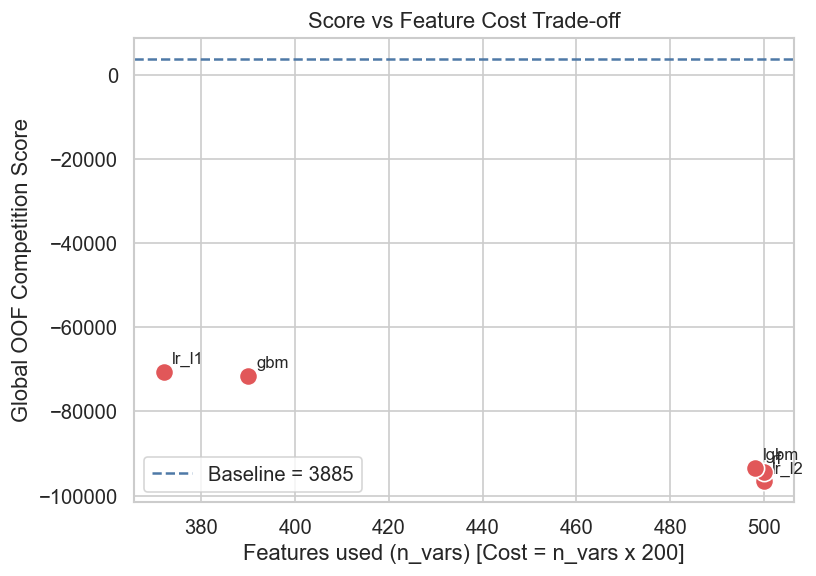

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results.items():
    color = '#59a14f' if res['score'] > BASELINE else '#e15759'

    ax.scatter(res['n_vars'], res['score'],
               s=120, color=color, zorder=5, edgecolors='white', linewidth=1)
    
    ax.annotate(name,
                xy=(res['n_vars'], res['score']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.axhline(BASELINE, color='#4e79a7', linestyle='--', linewidth=1.5,
           label=f'Baseline = {BASELINE}')

ax.set_xlabel('Features used (n_vars) [Cost = n_vars x 200]')
ax.set_ylabel('Global OOF Competition Score')
ax.set_title('Score vs Feature Cost Trade-off')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Model Selection Rationale

Use the cell below to interpret the results and decide which model to take forward.


In [10]:
print('=== FINAL RANKINGS ===')
print(f'Baseline: {BASELINE}\n')
ranked = sorted(results.items(), key=lambda x: -x[1]['score'])
for rank, (name, res) in enumerate(ranked, 1):
    beat = 'BEATS BASELINE' if res['score'] > BASELINE else 'below baseline'
    gain = res['score'] - BASELINE
    print(f"#{rank} {name:8s}  score={res['score']:6d}  "
          f"N={res['N']:5d}  n_vars={res['n_vars']:4d}  "
          f"thr={res['threshold']:.3f}  "
          f"TP={res['tp']}  FP={res['fp']}  "
          f"gain={gain:+d}  {beat}")


=== FINAL RANKINGS ===
Baseline: 3885

#1 lr_l1     score=-70580  N= 1000  n_vars= 372  thr=0.651  TP=588  FP=412  gain=-74465  below baseline
#2 gbm       score=-71480  N= 1000  n_vars= 390  thr=0.645  TP=768  FP=232  gain=-75365  below baseline
#3 lgbm      score=-93500  N= 1000  n_vars= 498  thr=0.759  TP=740  FP=260  gain=-97385  below baseline
#4 rf        score=-94275  N= 1000  n_vars= 500  thr=0.563  TP=715  FP=285  gain=-98160  below baseline
#5 lr_l2     score=-96585  N= 1000  n_vars= 500  thr=0.700  TP=561  FP=439  gain=-100470  below baseline


### Interpretation

- Any model with **OOF score > 3,885** beats the current best and should be considered for further tuning.
- Prefer models with **lower n_vars** when two models have similar scores - the €200/variable cost compounds quickly.
- **Threshold near 1/3**: the economic break-even probability is 1/3. If the optimal threshold deviates significantly, the model's probability ranking still works but the calibration is off — fine for ranking-based selection.
- **LR-L2** will score poorly because it uses all 500 features (cost = €100,000); it serves as an upper bound on predictive accuracy when feature cost is ignored.
- Tree models (RF, LGBM, XGB) implicitly select features via splits - check the `n_vars` column carefully. Models using 50+ features face a severe cost disadvantage.

**Key insight from this comparison**: the baseline models in `models.py` use default hyperparameters and the full 500-feature set. Tree models are heavily penalised by the NoVariables cost at this stage. The next step (notebooks 03–06) addresses this by identifying a small set of high-value features and tuning tree models on that reduced set - where they can fully exploit nonlinear signal without paying for hundreds of unused features.
